In [ ]:
import pandas as pd
import folium
from IPython.display import display
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import logging
import warnings

In [ ]:


# Carga de datos
df1 = pd.read_csv("https://raw.githubusercontent.com/AntoniaPache/Ciencia-de-datos-grupo-3/main/datasets-tpo/dat-ab-usos-2020.csv")
df2 = pd.read_csv("https://raw.githubusercontent.com/AntoniaPache/Ciencia-de-datos-grupo-3/main/datasets-tpo/dat-ab-usos-2021.csv")
df3 = pd.read_csv("https://raw.githubusercontent.com/AntoniaPache/Ciencia-de-datos-grupo-3/main/datasets-tpo/dat-ab-usos-2022.csv")
df4 = pd.read_csv("https://raw.githubusercontent.com/AntoniaPache/Ciencia-de-datos-grupo-3/main/datasets-tpo/dat-ab-usos-2023.csv")
df5 = pd.read_csv("https://raw.githubusercontent.com/AntoniaPache/Ciencia-de-datos-grupo-3/main/datasets-tpo/dat-ab-usos-2024.csv")
df6 = pd.read_csv("https://raw.githubusercontent.com/AntoniaPache/Ciencia-de-datos-grupo-3/main/datasets-tpo/dat-ab-usos-2025.csv")
df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)
df['PROVINCIA'] = df['PROVINCIA'].replace('CIUDAD AUTÓNOMA DE BUENOS AIRES', 'C.A.B.A')

# Preparación de datos
df['DIA_TRANSPORTE'] = pd.to_datetime(df['DIA_TRANSPORTE'])
df['AÑO'] = df['DIA_TRANSPORTE'].dt.year
df['MES'] = df['DIA_TRANSPORTE'].dt.month
df['MES_NOMBRE'] = df['DIA_TRANSPORTE'].dt.month_name()
df['DIA_SEMANA'] = df['DIA_TRANSPORTE'].dt.day_name()


In [ ]:
#Analisis explotario no estetico
print("Informacion general de los registros")
print(df.info())
print("Informacion general de los primeros 5 registros")
print(df.head())
print("Informacion general de la numeracion de provincias")
print(df['PROVINCIA'].unique())
print("Informacion general de los valores nulos ")
print(df.isnull().sum())
registros_con_nulos = df[df.isnull().any(axis=1)]
if not registros_con_nulos.empty:
    print(registros_con_nulos.head())

if not registros_con_nulos.empty:
    print("\n---")
    print("Análisis de repeticiones en registros con nulos:")

    # 1. Empresas que se repiten en registros con nulos
    print("Frecuencia de 'NOMBRE_EMPRESA' en registros con nulos:")
    empresas_con_nulos = registros_con_nulos['NOMBRE_EMPRESA'].value_counts()
    print(empresas_con_nulos.head(10))
    if len(empresas_con_nulos) > 10:
        print(f"...y {len(empresas_con_nulos) - 10} empresas más.")
    print("\n---")

    # 2. Medios de transporte que se repiten en registros con nulos
    print("Frecuencia de 'TIPO_TRANSPORTE' en registros con nulos:")
    medios_transporte_con_nulos = registros_con_nulos['TIPO_TRANSPORTE'].value_counts()
    print(medios_transporte_con_nulos)
    print("\n---")

    # 3. Fechas que se repiten en registros con nulos
    print("Frecuencia de 'DIA_TRANSPORTE' en registros con nulos:")
    fechas_con_nulos = registros_con_nulos['DIA_TRANSPORTE'].value_counts()
    print(fechas_con_nulos.head(10))
    if len(fechas_con_nulos) > 10:
        print(f"...y {len(fechas_con_nulos) - 10} fechas más.")
    print("\n---")

    # Cuántos de los registros con nulos pertenecen a AMBA
    print("Conteo de registros con nulos por región AMBA:")
    if 'AMBA' in registros_con_nulos.columns:
        # Filtramos y contamos cuántos de los registros nulos son de AMBA
        conteo_amba_nulos = registros_con_nulos['AMBA'].value_counts()
        print(conteo_amba_nulos)
    else:
        print("La columna 'AMBA' no se encuentra en los registros con nulos.")
    print("\n---")

   #Combinar para ver patrones más específicos
    print("Combinaciones frecuentes de Empresa, Tipo de Transporte y Fecha en registros con nulos:")
    combinaciones_nulos = registros_con_nulos[['NOMBRE_EMPRESA', 'TIPO_TRANSPORTE', 'DIA_TRANSPORTE']].value_counts()
    print(combinaciones_nulos.head(10))
    if len(combinaciones_nulos) > 10:
        print(f"...y {len(combinaciones_nulos) - 10} combinaciones más.")
    print("\n---")

# Rango de fechas de los registros con nulos
    print("Rango de fechas de los registros con nulos:")
    if not registros_con_nulos['DIA_TRANSPORTE'].empty:
        fecha_min_nulos = registros_con_nulos['DIA_TRANSPORTE'].min()
        fecha_max_nulos = registros_con_nulos['DIA_TRANSPORTE'].max()
        print(f"Desde: {fecha_min_nulos.strftime('%Y-%m-%d')}")
        print(f"Hasta: {fecha_max_nulos.strftime('%Y-%m-%d')}")
    else:
        print("No hay fechas disponibles en los registros con nulos (o no hay registros con nulos).")
    print("\n---")

Informacion general de los registros
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2407623 entries, 0 to 2407622
Data columns (total 14 columns):
 #   Column           Dtype         
---  ------           -----         
 0   DIA_TRANSPORTE   datetime64[ns]
 1   NOMBRE_EMPRESA   object        
 2   LINEA            object        
 3   AMBA             object        
 4   TIPO_TRANSPORTE  object        
 5   JURISDICCION     object        
 6   PROVINCIA        object        
 7   MUNICIPIO        object        
 8   CANTIDAD         int64         
 9   DATO_PRELIMINAR  object        
 10  AÑO              int32         
 11  MES              int32         
 12  MES_NOMBRE       object        
 13  DIA_SEMANA       object        
dtypes: datetime64[ns](1), int32(2), int64(1), object(10)
memory usage: 238.8+ MB
None
Informacion general de los primeros 5 registros
  DIA_TRANSPORTE                                     NOMBRE_EMPRESA  \
0     2020-01-01                                 EMP

                    RESUMEN GENERAL DEL DATASET



,Métrica,Valor
0,Período de datos,2020-01-01 a 2025-06-09
1,Total de registros,"2,407,623"
2,Empresas únicas,388
3,Líneas de transporte,1831
4,Provincias,23
5,Municipios,99
6,Cantidad total transportada,"18,833,056,514"



        PROVINCIAS INCLUIDAS


,Provincia
1,BUENOS AIRES
2,C.A.B.A
3,CATAMARCA
4,CHACO
5,CHUBUT
6,CORDOBA
7,CORRIENTES
8,ENTRE RÍOS
9,FORMOSA
10,JN



Valores nulos por columna:


...


Distribución por tipo de transporte:


,count
TIPO_TRANSPORTE,
COLECTIVO,2350412
TREN,34597
SUBTE,14286
LANCHAS,8319
CIRCULAR,9



Distribución por AMBA:


,count
AMBA,
NO,1603091
SI,804532



ANÁLISIS TEMPORAL Y GEOGRÁFICO
--------------------------------------------------


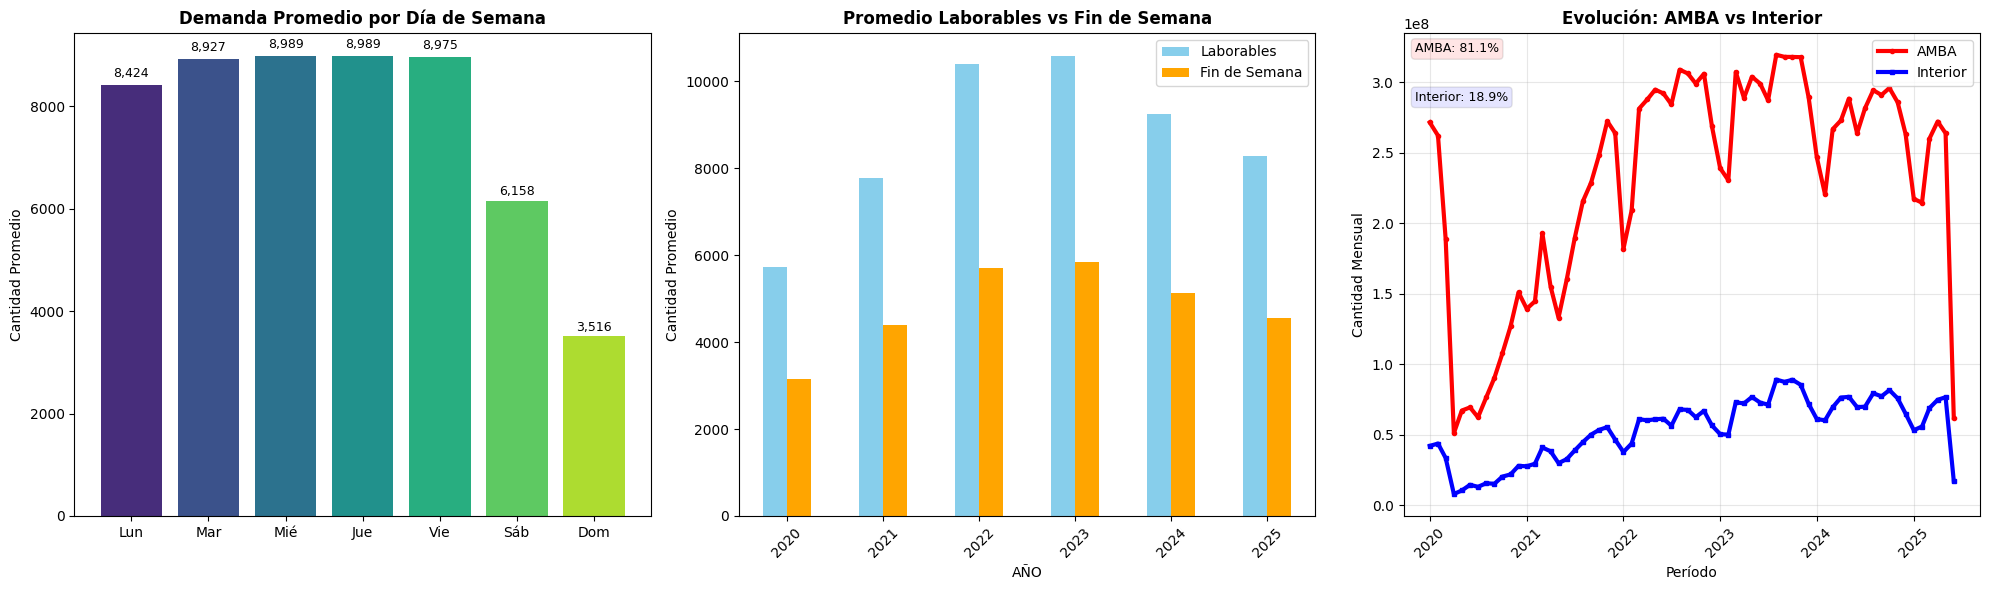


              ANÁLISIS DE CONCENTRACIÓN DE MERCADO


,Métrica,Valor
0,Top 5 empresas controlan,13.0% del mercado
1,Top 10 empresas controlan,20.1% del mercado
2,Top 20 empresas controlan,30.7% del mercado
3,Número total de empresas,388 empresas
4,Empresa líder (% mercado),3.9% (EMOVA MOVILIDAD S.A. (ex MTV)...)


In [ ]:
# Resumen general con formato estético
print("=" * 60)
print("                    RESUMEN GENERAL DEL DATASET")
print("=" * 60)
print()

# Crear DataFrame de resumen
resumen_data = {
    'Métrica': [
        'Período de datos',
        'Total de registros',
        'Empresas únicas',
        'Líneas de transporte',
        'Provincias',
        'Municipios',
        'Cantidad total transportada'
    ],
    'Valor': [
        f"{df['DIA_TRANSPORTE'].min().date()} a {df['DIA_TRANSPORTE'].max().date()}",
        f"{len(df):,}",
        f"{df['NOMBRE_EMPRESA'].nunique()}",
        f"{df['LINEA'].nunique()}",
        f"{df['PROVINCIA'].nunique()}",
        f"{df['MUNICIPIO'].nunique()}",
        f"{df['CANTIDAD'].sum():,}"
    ]
}

resumen_df = pd.DataFrame(resumen_data)
display(resumen_df)

print("\n" + "=" * 40)
print("        PROVINCIAS INCLUIDAS")
print("=" * 40)

# Crear DataFrame ordenado de provincias (sin NaN)
provincias_unicas = df['PROVINCIA'].dropna().unique()
provincias_df = pd.DataFrame({
    'Provincia': sorted(provincias_unicas)
})
provincias_df.index = provincias_df.index + 1  # Empezar índice en 1
display(provincias_df)

# Valores nulos
print("\nValores nulos por columna:")
display(df.isnull().sum())

# Distribuciones categóricas
print("\nDistribución por tipo de transporte:")
display(df['TIPO_TRANSPORTE'].value_counts())

print("\nDistribución por AMBA:")
display(df['AMBA'].value_counts())

# Configurar estilo para visualizaciones
plt.style.use('default')
sns.set_palette("husl")

# Preparar variables adicionales para análisis
df['DIA_SEMANA_NUM'] = df['DIA_TRANSPORTE'].dt.dayofweek
df['SEMANA_AÑO'] = df['DIA_TRANSPORTE'].dt.isocalendar().week
df['TRIMESTRE'] = df['DIA_TRANSPORTE'].dt.quarter
df['ES_FINDE'] = (df['DIA_SEMANA_NUM'] >= 5).astype(int)

print("\nANÁLISIS TEMPORAL Y GEOGRÁFICO")
print("-" * 50)

# Crear figura con 3 subplots en una fila
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# GRÁFICO Promedio por día de la semana
dow_data = df.groupby('DIA_SEMANA_NUM')['CANTIDAD'].mean()
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
bars = axes[0].bar(range(7), dow_data.values, color=sns.color_palette("viridis", 7))
axes[0].set_title('Demanda Promedio por Día de Semana', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dias)
axes[0].set_ylabel('Cantidad Promedio')

# Añadir valores en las barras
for bar, val in zip(bars, dow_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + val*0.01,
                  f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

# GRÁFICO Fin de semana vs días laborables
finde_comparison = df.groupby(['ES_FINDE', 'AÑO'])['CANTIDAD'].mean().reset_index()
finde_pivot = finde_comparison.pivot(index='AÑO', columns='ES_FINDE', values='CANTIDAD')
finde_pivot.columns = ['Laborables', 'Fin de Semana']
finde_pivot.plot(kind='bar', ax=axes[1], color=['skyblue', 'orange'])
axes[1].set_title('Promedio Laborables vs Fin de Semana', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cantidad Promedio')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()



# GRÁFICO  AMBA vs Interior
amba_evolution = df.groupby(['AÑO', 'MES', 'AMBA'])['CANTIDAD'].sum().reset_index()
amba_pivot = amba_evolution.pivot_table(index=['AÑO', 'MES'], columns='AMBA', values='CANTIDAD', fill_value=0)

if 'SI' in amba_pivot.columns and 'NO' in amba_pivot.columns:
    amba_monthly = amba_pivot.groupby(level=['AÑO', 'MES']).sum()
    amba_monthly.index = pd.to_datetime(amba_monthly.index.map(lambda x: f"{x[0]}-{x[1]:02d}-01"))

    axes[2].plot(amba_monthly.index, amba_monthly['SI'], label='AMBA', linewidth=3, color='red', marker='o', markersize=3)
    axes[2].plot(amba_monthly.index, amba_monthly['NO'], label='Interior', linewidth=3, color='blue', marker='s', markersize=3)

    axes[2].set_title('Evolución: AMBA vs Interior', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Cantidad Mensual')
    axes[2].set_xlabel('Período')
    axes[2].legend()
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].grid(True, alpha=0.3)

    # Añadir estadísticas
    total_amba = amba_monthly['SI'].sum()
    total_interior = amba_monthly['NO'].sum()
    pct_amba = (total_amba / (total_amba + total_interior)) * 100

    axes[2].text(0.02, 0.98, f'AMBA: {pct_amba:.1f}%',
                transform=axes[2].transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='red', alpha=0.1))
    axes[2].text(0.02, 0.88, f'Interior: {100-pct_amba:.1f}%',
                transform=axes[2].transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='blue', alpha=0.1))

else:
    axes[2].text(0.5, 0.5, 'No hay datos suficientes\npara AMBA vs Interior',
                transform=axes[2].transAxes, ha='center', va='center', fontsize=12)
    axes[2].set_title('AMBA vs Interior', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ANÁLISIS DE CONCENTRACIÓN Y MERCADO
print("\n" + "="*60)
print("              ANÁLISIS DE CONCENTRACIÓN DE MERCADO")
print("="*60)

# Calcular métricas de concentración
total_pasajeros = df['CANTIDAD'].sum()
empresas_stats_calc = df.groupby('NOMBRE_EMPRESA')['CANTIDAD'].sum().sort_values(ascending=False)

# Calcular participaciones acumuladas
participaciones = (empresas_stats_calc / total_pasajeros * 100).cumsum()

concentracion_data = {
    'Métrica': [
        'Top 5 empresas controlan',
        'Top 10 empresas controlan',
        'Top 20 empresas controlan',
        'Número total de empresas',
        'Empresa líder (% mercado)'
    ],
    'Valor': [
        f"{participaciones.iloc[4]:.1f}% del mercado",
        f"{participaciones.iloc[9]:.1f}% del mercado",
        f"{participaciones.iloc[19]:.1f}% del mercado" if len(participaciones) > 19 else "N/A",
        f"{len(empresas_stats_calc)} empresas",
        f"{empresas_stats_calc.iloc[0]/total_pasajeros*100:.1f}% ({empresas_stats_calc.index[0][:30]}...)"
    ]
}
concentracion_df = pd.DataFrame(concentracion_data)
display(concentracion_df)

In [ ]:
print("Distribución por total de pasajeros transportados:")
display(df.groupby('PROVINCIA')['CANTIDAD'].sum().sort_values(ascending=False).head(10))


# MAPA INTERACTIVO
# Coordenadas aproximadas de las provincias argentinas
provincias_coords = {
    'BUENOS AIRES': [-36.6769, -60.5588],
    'MENDOZA': [-32.8908, -68.8272],
    'SANTA FE': [-31.6333, -60.7000],
    'SAN JUAN': [-31.5375, -68.5364],
    'JUJUY': [-24.1858, -65.2995],
    'NEUQUÉN': [-38.9516, -68.0591],
    'CHUBUT': [-43.2493, -65.1814],
    'ENTRE RÍOS': [-32.0588, -59.2014],
    'RÍO NEGRO': [-40.8135, -63.0000],
    'CÓRDOBA': [-31.4201, -64.1888],
    'CORRIENTES': [-27.4806, -58.8341],
    'MISIONES': [-26.8754, -54.6568],
    'SALTA': [-24.7821, -65.4232],
    'TUCUMÁN': [-26.8083, -65.2176],
    'SANTIAGO DEL ESTERO': [-27.7824, -64.2642],
    'CATAMARCA': [-28.4696, -65.7852],
    'LA RIOJA': [-29.4331, -66.8563],
    'SAN LUIS': [-33.2949, -66.3361],
    'LA PAMPA': [-36.6167, -64.2833],
    'SANTA CRUZ': [-48.8647, -69.9618],
    'TIERRA DEL FUEGO': [-54.8019, -68.3030],
    'FORMOSA': [-26.1775, -58.1781],
    'C.A.B.A': [-34.6037, -58.3816] # Añadir C.A.B.A. a las coordenadas
}

# Crear mapa base centrado en Argentina
mapa = folium.Map(
    location=[-38.4161, -63.6167],  # Centro de Argentina
    zoom_start=5,
    tiles='OpenStreetMap'
)

# Procesar datos por provincia
provincia_stats = df.groupby('PROVINCIA').agg({
    'CANTIDAD': ['sum', 'mean', 'count'],
    'NOMBRE_EMPRESA': 'nunique',
    'TIPO_TRANSPORTE': lambda x: x.value_counts().to_dict()
}).round(2)

# Aplanar los nombres de columnas
provincia_stats.columns = ['total_cantidad', 'promedio_cantidad', 'num_registros', 'num_empresas', 'tipos_transporte']

# Agregar marcadores por provincia
for provincia in provincia_stats.index:
    if provincia in provincias_coords:
        coords = provincias_coords[provincia]
        stats = provincia_stats.loc[provincia]

        # Determinar el tamaño del marcador basado en el total transportado
        max_total = provincia_stats['total_cantidad'].max()
        radio = max(8, min(50, (stats['total_cantidad'] / max_total) * 40))

        # Crear información del popup
        tipos_transport_str = ""
        if isinstance(stats['tipos_transporte'], dict):
            for tipo, cantidad in stats['tipos_transporte'].items():
                tipos_transport_str += f"  • {tipo}: {cantidad:,}<br>"

        popup_html = f"""
        <div style="width: 200px;">
            <h4 style="margin-bottom: 10px; color: #2E86AB;">{provincia}</h4>
            <hr style="margin: 5px 0;">
            <b>Estadísticas Generales:</b><br>
            • Total transportado: <b>{stats['total_cantidad']:,.0f}</b><br>
            • Promedio diario: <b>{stats['promedio_cantidad']:,.0f}</b><br>
            • Número de registros: <b>{stats['num_registros']:,}</b><br>
            • Empresas activas: <b>{stats['num_empresas']}</b><br>
            <br>
            <b>Por tipo de transporte:</b><br>
            {tipos_transport_str}
        </div>
        """

        # Determinar color basado en el volumen de transporte
        if stats['total_cantidad'] > 50000000:  # Alto volumen
            color = 'red'
        elif stats['total_cantidad'] > 10000000:  # Volumen medio
            color = 'orange'
        else:  # Volumen bajo
            color = 'green'

        folium.CircleMarker(
            location=coords,
            radius=radio,
            popup=folium.Popup(popup_html, max_width=250),
            tooltip=f"{provincia}: {stats['total_cantidad']:,.0f} pasajeros",
            color='darkblue',
            fill=True,
            fillColor=color,
            fillOpacity=0.7,
            weight=2
        ).add_to(mapa)

# Agregar marcador especial para AMBA
amba_data = df[df['AMBA'] == 'SI']
folium.Marker(
    [-34.6118, -58.3960],  # Buenos Aires
    popup=f"""
    <div style="width: 200px;">
        <h4 style="color: #A23B72;">ÁREA METROPOLITANA</h4>
        <hr>
        <b>Registros AMBA:</b> {len(amba_data):,}<br>
        <b>Total transportado:</b> {amba_data['CANTIDAD'].sum():,}<br>
        <b>Promedio diario:</b> {amba_data['CANTIDAD'].mean():.0f}<br>
        <b>Empresas:</b> {amba_data['NOMBRE_EMPRESA'].nunique()}<br>
        <b>Líneas:</b> {amba_data['LINEA'].nunique()}
    </div>
    """,
    tooltip="Área Metropolitana de Buenos Aires",
    icon=folium.Icon(color='purple', icon='bus', prefix='fa')
).add_to(mapa)

# Agregar leyenda
leyenda_html = '''
<div style="position: fixed;
            top: 10px; right: 10px; width: 180px; height: 120px;
            z-index:9999;
            font-size:14px; padding: 10px">
<p><i class="fa fa-circle" style="color:red"></i> Alto volumen (>50M)</p>
<p><i class="fa fa-circle" style="color:orange"></i> Volumen medio (10-50M)</p>
<p><i class="fa fa-circle" style="color:green"></i> Volumen bajo (<10M)</p>
<p><i class="fa fa-bus" style="color:purple"></i> AMBA</p>
</div>
'''
mapa.get_root().html.add_child(folium.Element(leyenda_html))

# Mostrar el mapa interactivo
print("\nMAPA INTERACTIVO DE TRANSPORTE EN ARGENTINA")
print("=" * 50)
display(mapa)

Distribución por total de pasajeros transportados:


,CANTIDAD
PROVINCIA,
BUENOS AIRES,7528854249
JN,7368195599
MENDOZA,897037188
SANTA FE,464372216
SAN JUAN,388471413
JUJUY,297550118
ENTRE RÍOS,124496647
CORRIENTES,119861879
CHACO,115177086



MAPA INTERACTIVO DE TRANSPORTE EN ARGENTINA



Shape final de X: (2104160, 7)
Shape final de y: (2104160,)

Entrenando modelo con muestra de 100,000 filas...

=== ML: Predicción de demanda diaria por municipio y tipo de transporte ===

                   RESULTADOS RANDOM FOREST

📊 MÉTRICAS DE RENDIMIENTO:


,Métrica,Valor,Interpretación
0,MAE (Error Absoluto Medio),"13,364",Promedio de error absoluto
1,RMSE (Raíz Error Cuadrático),"43,123",Penaliza errores grandes
2,R² (Coeficiente Determinación),0.857,Explica 85.7% de la varianza



🎯 IMPORTANCIA DE VARIABLES:


,Variable,Código,Importancia,Porcentaje
4,Municipio,MUNI_CAT,0.340,34.0%
5,Tipo de transporte,TIPO_CAT,0.223,22.3%
3,Provincia,PROV_CAT,0.210,21.0%
2,Pertenece a AMBA,es_amba,0.174,17.4%
1,Es fin de semana,es_finde,0.036,3.6%
0,Mes del año,MES,0.017,1.7%



🔍 EJEMPLOS DE PREDICCIÓN:


,Caso,Valor Real,Predicción,Error Absoluto,Error %
0,Ejemplo 1,"27,048","26,376",672,2.5%
1,Ejemplo 2,"17,629","20,446","2,817",16.0%
2,Ejemplo 3,"29,644","27,877","1,767",6.0%
3,Ejemplo 4,"8,159","5,668","2,491",30.5%
4,Ejemplo 5,"1,738","3,325","1,587",91.3%




Tabla de ejemplos de predicción (menor error primero):


,MES,Municipio,Provincia,TipoTransporte,Real,Predicho,Error_abs
67023,6,VILLA ALLENDE,CORDOBA,COLECTIVO,24,23.875000,0.125000
112294,12,SAN PEDRO,BUENOS AIRES,COLECTIVO,275,275.316884,0.316884
73398,9,VILLA ALLENDE,CORDOBA,COLECTIVO,142,141.532734,0.467266
47559,10,VILLA ALLENDE,CORDOBA,COLECTIVO,140,139.527046,0.472954
105282,9,VILLA ALLENDE,CORDOBA,COLECTIVO,141,141.532734,0.532734
149072,1,PUERTO GENERAL SAN MARTIN,SANTA FE,COLECTIVO,69,69.584444,0.584444
141143,11,PUNTA INDIO,BUENOS AIRES,COLECTIVO,4,3.333333,0.666667
125369,5,VILLA ALLENDE,CORDOBA,COLECTIVO,119,119.864372,0.864372
95121,6,VILLA ALLENDE,CORDOBA,COLECTIVO,23,23.875000,0.875000
143606,11,RIO CUARTO,CORDOBA,COLECTIVO,6048,6046.973650,1.026350


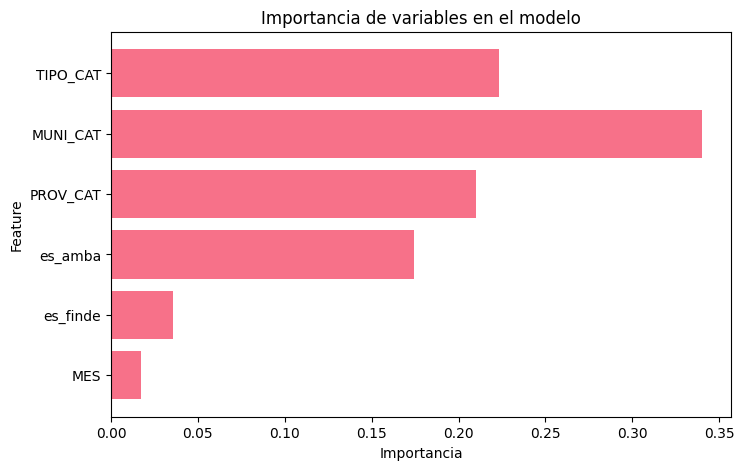

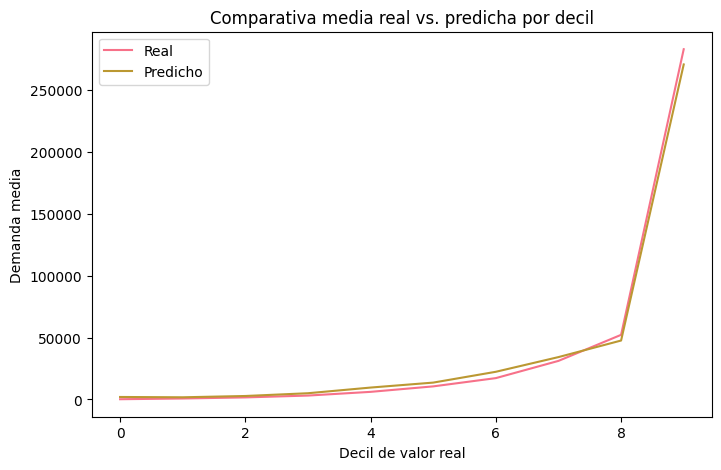

DEBUG:cmdstanpy:input tempfile: /tmp/tmpp4z_bl3d/u_a9ha7l.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpp4z_bl3d/o_oqktzw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=44086', 'data', 'file=/tmp/tmpp4z_bl3d/u_a9ha7l.json', 'init=/tmp/tmpp4z_bl3d/o_oqktzw.json', 'output', 'file=/tmp/tmpp4z_bl3d/prophet_modelmcfu_vm0/prophet_model-20250624194941.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
19:49:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:49:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


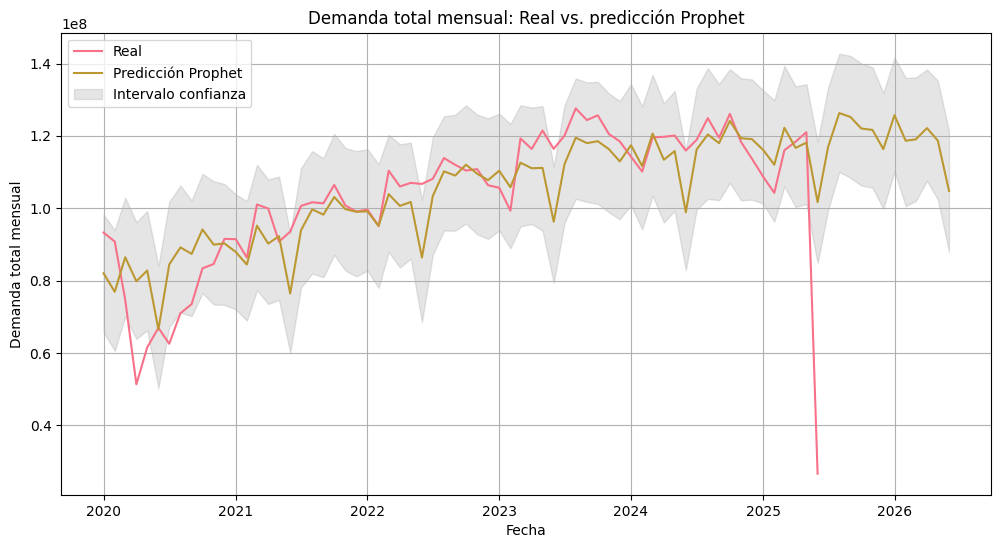

In [ ]:
# PIPELINE DE LIMPIEZA Y FEATURES

# Suprimir logs de debug de Prophet/CmdStan
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

# 1. LIMPIEZA DE NULOS Y VALORES NEGATIVOS
df_clean = df.dropna(subset=['PROVINCIA', 'MUNICIPIO', 'CANTIDAD'])
df_clean = df_clean[df_clean['CANTIDAD'] > 0]

# 2. FILTRADO DE OUTLIERS EN CANTIDAD (IQR)
Q1 = df_clean['CANTIDAD'].quantile(0.25)
Q3 = df_clean['CANTIDAD'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR
limite_inf = Q1 - 1.5 * IQR
df_clean = df_clean[(df_clean['CANTIDAD'] <= limite_sup) & (df_clean['CANTIDAD'] >= limite_inf)]

# 3. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
le_prov = LabelEncoder()
le_muni = LabelEncoder()
le_tipo = LabelEncoder()
df_clean['PROV_CAT'] = le_prov.fit_transform(df_clean['PROVINCIA'])
df_clean['MUNI_CAT'] = le_muni.fit_transform(df_clean['MUNICIPIO'])
df_clean['TIPO_CAT'] = le_tipo.fit_transform(df_clean['TIPO_TRANSPORTE'])

# 4. CREACIÓN DE FEATURES ÚTILES
df_clean['es_finde'] = df_clean['DIA_SEMANA'].isin(['Saturday', 'Sunday']).astype(int)
df_clean['es_amba'] = (df_clean['AMBA'] == 'SI').astype(int)

# 5. DATASET FINAL PARA ML
features = ['AÑO', 'MES', 'es_finde', 'es_amba', 'PROV_CAT', 'MUNI_CAT', 'TIPO_CAT']
X = df_clean[features]
y = df_clean['CANTIDAD']

print('\nShape final de X:', X.shape)
print('Shape final de y:', y.shape)

# Tomar una muestra aleatoria de 100,000 filas para entrenamiento rápido
X_sample, y_sample = shuffle(X, y, random_state=42)
X_sample = X_sample[:100000]
y_sample = y_sample[:100000]

print('\nEntrenando modelo con muestra de 100,000 filas...')

# =============================
# EXPERIMENTO ML: Random Forest
# =============================

# Train/test split con la muestra
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# Entrenamiento (menos árboles para mayor velocidad)
rf = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predicción y métricas
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# =============================
# ML: Predicción de demanda diaria por municipio y tipo de transporte (sin AÑO)
# =============================

print("\n=== ML: Predicción de demanda diaria por municipio y tipo de transporte ===")

# Agrupar datos por municipio, tipo de transporte y día
agg_cols = ['DIA_TRANSPORTE', 'MUNICIPIO', 'TIPO_TRANSPORTE', 'PROVINCIA', 'AÑO', 'MES', 'DIA_SEMANA', 'AMBA']
df_group = df_clean.groupby(agg_cols)['CANTIDAD'].sum().reset_index()

# Codificamos y generamos features en df_group después del groupby
le_muni2 = LabelEncoder()
le_tipo2 = LabelEncoder()
le_prov2 = LabelEncoder()
df_group['MUNI_CAT'] = le_muni2.fit_transform(df_group['MUNICIPIO'])
df_group['TIPO_CAT'] = le_tipo2.fit_transform(df_group['TIPO_TRANSPORTE'])
df_group['PROV_CAT'] = le_prov2.fit_transform(df_group['PROVINCIA'])
df_group['es_finde'] = df_group['DIA_SEMANA'].isin(['Saturday', 'Sunday']).astype(int)
df_group['es_amba'] = (df_group['AMBA'] == 'SI').astype(int)

# Features sin 'AÑO'
features2 = ['MES', 'es_finde', 'es_amba', 'PROV_CAT', 'MUNI_CAT', 'TIPO_CAT']
X2 = df_group[features2]
y2 = df_group['CANTIDAD']

# Muestra para entrenamiento rápido
X2_sample, y2_sample = shuffle(X2, y2, random_state=42)
X2_sample = X2_sample[:50000]
y2_sample = y2_sample[:50000]

# Train/test split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_sample, y2_sample, test_size=0.2, random_state=42)

# Modelo base: predice la media histórica
y2_base = np.full_like(y2_test, y2_train.mean())

# Random Forest
rf2 = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1)
rf2.fit(X2_train, y2_train)
y2_pred = rf2.predict(X2_test)

# Métricas
mae_rf = mean_absolute_error(y2_test, y2_pred)
rmse_rf = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_rf = r2_score(y2_test, y2_pred)

# =============================
# RESULTADOS DEL MODELO RANDOM FOREST
# =============================

print("\n" + "="*60)
print("                   RESULTADOS RANDOM FOREST")
print("="*60)

# Métricas principales en formato tabla
metricas_data = {
    'Métrica': ['MAE (Error Absoluto Medio)', 'RMSE (Raíz Error Cuadrático)', 'R² (Coeficiente Determinación)'],
    'Valor': [f"{mae_rf:,.0f}", f"{rmse_rf:,.0f}", f"{r2_rf:.3f}"],
    'Interpretación': [
        'Promedio de error absoluto',
        'Penaliza errores grandes',
        f"Explica {r2_rf*100:.1f}% de la varianza"
    ]
}
metricas_df = pd.DataFrame(metricas_data)
print("\n📊 MÉTRICAS DE RENDIMIENTO:")
display(metricas_df)

# Importancia de features en formato tabla
importances2 = rf2.feature_importances_
feature_names = {
    'MES': 'Mes del año',
    'es_finde': 'Es fin de semana',
    'es_amba': 'Pertenece a AMBA',
    'PROV_CAT': 'Provincia',
    'MUNI_CAT': 'Municipio',
    'TIPO_CAT': 'Tipo de transporte'
}

importancia_data = {
    'Variable': [feature_names[feat] for feat in features2],
    'Código': features2,
    'Importancia': [f"{imp:.3f}" for imp in importances2],
    'Porcentaje': [f"{imp*100:.1f}%" for imp in importances2]
}
importancia_df = pd.DataFrame(importancia_data)
importancia_df = importancia_df.sort_values('Importancia', ascending=False, key=lambda x: x.astype(float))
print("\n🎯 IMPORTANCIA DE VARIABLES:")
display(importancia_df)

# Ejemplos de predicción en formato tabla
ejemplos_data = {
    'Caso': [f"Ejemplo {i+1}" for i in range(5)],
    'Valor Real': [f"{y2_test.iloc[i]:,.0f}" for i in range(5)],
    'Predicción': [f"{y2_pred[i]:,.0f}" for i in range(5)],
    'Error Absoluto': [f"{abs(y2_test.iloc[i] - y2_pred[i]):,.0f}" for i in range(5)],
    'Error %': [f"{abs(y2_test.iloc[i] - y2_pred[i])/y2_test.iloc[i]*100:.1f}%" for i in range(5)]
}
ejemplos_df = pd.DataFrame(ejemplos_data)
print("\n🔍 EJEMPLOS DE PREDICCIÓN:")
display(ejemplos_df)

print("\n" + "="*60)

# Mostrar tabla de ejemplos de predicción (menor error primero)
ejemplo_df = X2_test.copy()
ejemplo_df['Real'] = y2_test.values
ejemplo_df['Predicho'] = y2_pred
ejemplo_df['Error_abs'] = np.abs(ejemplo_df['Real'] - ejemplo_df['Predicho'])
ejemplo_df['Municipio'] = le_muni2.inverse_transform(ejemplo_df['MUNI_CAT'].astype(int))
ejemplo_df['TipoTransporte'] = le_tipo2.inverse_transform(ejemplo_df['TIPO_CAT'].astype(int))
ejemplo_df['Provincia'] = le_prov2.inverse_transform(ejemplo_df['PROV_CAT'].astype(int))
ejemplo_df = ejemplo_df.sort_values('Error_abs')
print("\nTabla de ejemplos de predicción (menor error primero):")
display(ejemplo_df[['MES', 'Municipio', 'Provincia', 'TipoTransporte', 'Real', 'Predicho', 'Error_abs']].head(10))

# 1. Importancia de features (Feature Importance)
plt.figure(figsize=(8,5))
importances = rf2.feature_importances_
plt.barh(features2, importances)
plt.title('Importancia de variables en el modelo')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.show()

# 3. Comparativa de reales vs. predichos por decil
# (usando ejemplo_df generado previamente)
ejemplo_df['decil_real'] = pd.qcut(ejemplo_df['Real'], 10, labels=False)
grouped = ejemplo_df.groupby('decil_real')[['Real', 'Predicho']].mean().reset_index()
plt.figure(figsize=(8,5))
plt.plot(grouped['decil_real'], grouped['Real'], label='Real')
plt.plot(grouped['decil_real'], grouped['Predicho'], label='Predicho')
plt.title('Comparativa media real vs. predicha por decil')
plt.xlabel('Decil de valor real')
plt.ylabel('Demanda media')
plt.legend()
plt.show()

# =============================
# Series temporales: Prophet para demanda total mensual
# =============================

# 1. Crear serie mensual total
serie_mensual = df_clean.groupby([df_clean['DIA_TRANSPORTE'].dt.to_period('M')])['CANTIDAD'].sum().reset_index()
serie_mensual['ds'] = serie_mensual['DIA_TRANSPORTE'].dt.to_timestamp()
serie_mensual = serie_mensual.rename(columns={'CANTIDAD': 'y'})[['ds', 'y']]

# 2. Entrenar Prophet
modelo_prophet = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
modelo_prophet.fit(serie_mensual)

# 3. Hacer predicción hasta diciembre 2026
future = modelo_prophet.make_future_dataframe(periods=12, freq='ME')  # Usar 'ME' en lugar de 'M'
forecast = modelo_prophet.predict(future)

# 4. Gráfico de ajuste y predicción
plt.figure(figsize=(12,6))
plt.plot(serie_mensual['ds'], serie_mensual['y'], label='Real')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicción Prophet')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='gray', alpha=0.2, label='Intervalo confianza')
plt.title('Demanda total mensual: Real vs. predicción Prophet')
plt.xlabel('Fecha')
plt.ylabel('Demanda total mensual')
plt.legend()
plt.grid(True)
plt.show()